## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Kathryn Choi

**Date:** [To be provided]

In [ ]:
# Your Phase 1 solution to the problem goes here.

QUESTION 1
1.   Regression predicts continuous numerical values using labeled data whereas classification predicts discrete labels or categories.
2.   A confusion table/matrix compares the predicted outputs of a machine learning model to real-world values in order to help us understand how well a classification model performs.
3. The sum of square error (SSE) helps to quantify the unexplained variance between the observed data points and model's predicted values.
4. Overfitting happens when a model is highly accurate for the training data but inaccurate for new data due to the model's memorization of the training data's specific patterns rather than generalized data patterns. Underfitting happens when a model fails to capture the general structure and trends in the data due to the oversimplification of the model.
5. Splitting data into training and testing sets helps to prevent overfitting by forcing the model on work on new, unseen data. Choosing k by evaluating SSE on the test set allows for a k value that is not overfitted or underfitted, thus improving the overall performance of the model.
6. Reporting class labels as predictions has strengths such as simplicity in interpretation and easy system integration, but weaknesses such as loss of information and unknown uncertainity measures. Using probability distributions over class labels has advantages such as defined uncertainity and flexibility in decision making, but disadvantages such as being more difficult to comprehend and integrate.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


,count
mine_type,
1,71
2,70
3,66
4,66
5,65


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


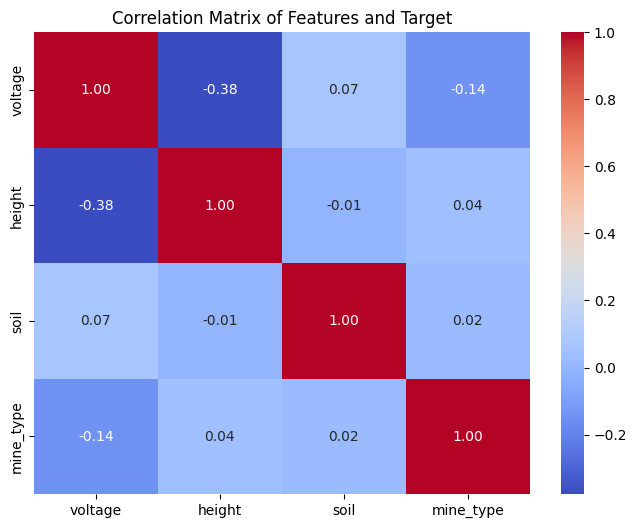

In [2]:
# QUESTION 2.1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
df = pd.read_csv('/content/drive/MyDrive/Semester 5 - Fall 2026/DS 3001 - Intro to Machine Learning/A03 - kNN/land_mines.csv')

# EDA
display(df['mine_type'].value_counts().sort_index())
display(df[['voltage', 'height', 'soil']].describe())
  # Correlation Matrix of Features
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features and Target')
plt.show()

In [3]:
# QUESTION 2.2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X = df[['voltage', 'height', 'soil']]
y = df[['mine_type']]
(
    X_train,
    X_valid,
    y_train,
    y_valid,
) = train_test_split(
    X, y, test_size = 0.5, random_state = 65
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Ensuring an even 50-50 split
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_valid.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_valid.shape)

Shape of X_train: (169, 3)
Shape of X_test: (169, 3)
Shape of y_train: (169, 1)
Shape of y_test: (169, 1)


In [4]:
# QUESTION 2.3
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Selecting k
ks = np.arange(1, 21)
valid_sse = []
train_sse = []

for k in ks:
  candidate = KNeighborsClassifier(n_neighbors=int(k))
  candidate.fit(X_train_scaled, y_train)
  valid_hat = candidate.predict(X_valid_scaled)
  train_hat = candidate.predict(X_train_scaled)
  valid_sse.append(np.sum(
      (y_valid.to_numpy() - valid_hat) ** 2
  ))
  train_sse.append(np.sum(
      (y_train.to_numpy() - train_hat) ** 2
  ))
k_star = int(ks[np.argmin(valid_sse)])
print('Optimal k:', k_star)

# The optimal k was selected by evaulating the model's performance over a range of k values, training a kNN classification
# model for each k, and calculating the SSE on the validation dataset. The k value with the smallest SSE was identified as the optimal k.


# Building kNN classifier
class_X = df[['voltage', 'height', 'soil']]
class_y = df[['mine_type']]
class_scaler = MinMaxScaler()
class_X_scaled = pd.DataFrame(
    class_scaler.fit_transform(class_X),
    columns=class_X.columns,
    index=class_X.index
)
class_model = KNeighborsClassifier(n_neighbors=k_star).fit(
    class_X_scaled, class_y
)

/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

Optimal k: 2


/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [8]:
# QUESTION 2.4
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd

# Creating Confusion Matrix
optimal_class = KNeighborsClassifier(n_neighbors=k_star)
optimal_class.fit(X_train_scaled, y_train.values.ravel())

y_pred = optimal_class.predict(X_valid_scaled)

con_matrix = confusion_matrix(y_valid, y_pred)
display(pd.DataFrame(con_matrix,
                     index=[f'True {c}' for c in optimal_class.classes_], columns=[f'Pred {c}' for c in optimal_class.classes_]))

# Calculating Accuracy
overall_accuracy = accuracy_score(y_valid, y_pred)
print(f"Overall Accuracy: {overall_accuracy * 100:.2f}%")
print(classification_report(y_valid, y_pred))


# Based on the confusion matrix, the optimal classification model is roughly 44.97% accurate, meaning that it correctly classifies a
# mine type less than half of the time. For mine type 2, the model is around 73% accurate, making it the most accurately classified
# mine type. The other mine types are correctly classified around 30-43% of the time, making them less accurate.

,Pred 1,Pred 2,Pred 3,Pred 4,Pred 5
True 1,21,1,6,4,2
True 2,0,33,2,3,0
True 3,5,5,10,6,4
True 4,13,5,10,9,1
True 5,10,1,8,7,3


Overall Accuracy: 44.97%
              precision    recall  f1-score   support

           1       0.43      0.62      0.51        34
           2       0.73      0.87      0.80        38
           3       0.28      0.33      0.30        30
           4       0.31      0.24      0.27        38
           5       0.30      0.10      0.15        29

    accuracy                           0.45       169
   macro avg       0.41      0.43      0.41       169
weighted avg       0.42      0.45      0.42       169



**QUESTION 2.5**

Given the 44.97% accuracy rate, I would advise someone using this predictive model to not use this model as the main tool for classifiying mine types and instead use it as an initial baseline screening of the data for certain mine types with higher accuracy since the cost of missing a mine (Type II error) is significant and occurs frequently for mine types like 4 and 5.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]